# Scattering features for modulation recognition

This CPU-friendly experiment compares downsampled IQ, FFT magnitude, and scattering features using the same small classifier. Synthetic BPSK, QPSK, 2-FSK, and chirp examples receive random phase, timing, frequency offset, and SNR. It illustrates methodology, not a universal performance claim.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torchsig_models.utils.training import set_deterministic

set_deterministic(19)
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
N=512; SPS=8; NAMES=["BPSK","QPSK","2-FSK","LFM"]
FREQUENCIES=torch.logspace(np.log10(.015),np.log10(.42),10)


In [2]:
def morlet_bank(length, frequencies, cycles=6.0):
    time = torch.arange(length) - length // 2
    filters = []
    for frequency in frequencies:
        sigma = cycles / (2 * torch.pi * frequency)
        wavelet = torch.exp(-0.5 * (time / sigma).square())
        wavelet = wavelet * torch.exp(2j * torch.pi * frequency * time)
        wavelet = wavelet - wavelet.mean()
        filters.append(wavelet / wavelet.abs().square().sum().sqrt())
    return torch.stack(filters)

def wavelet_modulus(signals, wavelets):
    spectrum = torch.fft.fft(signals, dim=-1)
    filters = torch.fft.fft(torch.fft.ifftshift(wavelets, dim=-1), dim=-1)
    return torch.fft.ifft(spectrum.unsqueeze(-2) * filters, dim=-1).abs()

def scattering_features(signals, wavelets):
    if signals.ndim == 1:
        signals = signals.unsqueeze(0)
    first = wavelet_modulus(signals, wavelets)
    features = [signals.abs().mean(-1, keepdim=True), first.mean(-1)]
    second = []
    for j in range(1, wavelets.shape[0]):
        envelopes = wavelet_modulus(first[:, j], wavelets)
        second.append(envelopes[:, :j].mean(-1))
    features.append(torch.cat(second, dim=-1))
    return torch.cat(features, dim=-1)

WAVELETS=morlet_bank(N,FREQUENCIES)

def example(kind):
    count=N//SPS; t=torch.arange(N)
    if kind==0:
        x=(2*torch.randint(0,2,(count,))-1).repeat_interleave(SPS).to(torch.complex64)
    elif kind==1:
        x=torch.exp(1j*torch.randint(0,4,(count,))*torch.pi/2).repeat_interleave(SPS)
    elif kind==2:
        f=torch.where(torch.randint(0,2,(count,)).bool(),.09,-.09).repeat_interleave(SPS)
        x=torch.exp(2j*torch.pi*torch.cumsum(f,0))
    else:
        x=torch.exp(2j*torch.pi*torch.cumsum(-.15+.30*t/N,0))
    x*=torch.exp(1j*(2*torch.pi*torch.rand(())+2*torch.pi*(.04*torch.rand(())-.02)*t))
    x=torch.roll(x,int(torch.randint(0,N,(1,))))
    x/=x.abs().square().mean().sqrt()
    snr=-4+24*torch.rand(()); scale=10**(-snr/20)/np.sqrt(2)
    return x+scale*(torch.randn(N)+1j*torch.randn(N))

def dataset(per_class):
    xs=[]; ys=[]
    for y in range(len(NAMES)):
        for _ in range(per_class): xs.append(example(y)); ys.append(y)
    p=torch.randperm(len(ys))
    return torch.stack(xs)[p],torch.tensor(ys)[p]

train_x,train_y=dataset(120); test_x,test_y=dataset(60)
print(train_x.shape)


torch.Size([480, 512])


## Fixed representations and a shared classifier

Only the frontend changes. Feature standardization is fitted on the training split.

In [3]:
def features(x,name):
    if name=="iq":
        z=x[:,::8]; return torch.cat((z.real,z.imag),-1)
    if name=="spectrum":
        return torch.fft.fft(x).abs()[:,:N//2]
    if name=="scattering":
        return scattering_features(x,WAVELETS)
    raise ValueError(name)

def fit(x,y):
    mean=x.mean(0,keepdim=True); std=x.std(0,keepdim=True).clamp_min(1e-5)
    z=((x-mean)/std).to(DEVICE); y=y.to(DEVICE)
    model=nn.Sequential(nn.Linear(z.shape[1],64),nn.ReLU(),nn.Linear(64,len(NAMES))).to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=2e-3)
    for _ in range(100):
        opt.zero_grad(); loss=nn.functional.cross_entropy(model(z),y)
        loss.backward(); opt.step()
    return model,mean,std

results={}
for name in ("iq","spectrum","scattering"):
    a=features(train_x,name); b=features(test_x,name)
    model,mean,std=fit(a,train_y)
    with torch.no_grad(): pred=model(((b-mean)/std).to(DEVICE)).argmax(1).cpu()
    results[name]=pred
    print(f"{name:10} dimension={a.shape[1]:3d} accuracy={(pred==test_y).float().mean():.2%}")


iq         dimension=128 accuracy=28.33%
spectrum   dimension=256 accuracy=74.17%
scattering dimension= 56 accuracy=80.83%


## Confusion matrices and interpretation

Scattering should help separate families with different time-frequency envelopes. Phase-only distinctions can become harder because modulus intentionally removes global phase.

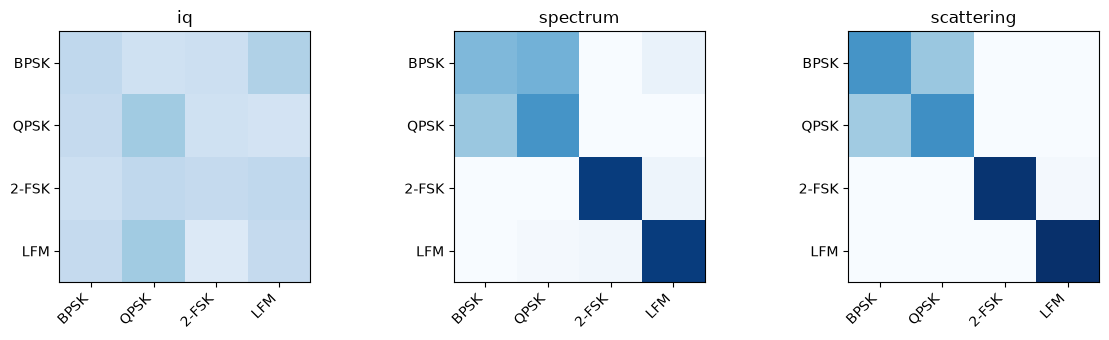

In [4]:
fig,axes=plt.subplots(1,3,figsize=(12,3.5))
for ax,(name,pred) in zip(axes,results.items()):
    matrix=torch.zeros(4,4)
    matrix.view(-1).scatter_add_(0,test_y*4+pred,torch.ones_like(test_y,dtype=torch.float))
    matrix/=matrix.sum(1,keepdim=True).clamp_min(1)
    ax.imshow(matrix,vmin=0,vmax=1,cmap="Blues"); ax.set_title(name)
    ax.set_xticks(range(4),NAMES,rotation=45,ha="right"); ax.set_yticks(range(4),NAMES)
plt.tight_layout()


## Using scattering with TorchSig

Generate complex TorchSig IQ examples, then apply scattering dynamically in a dataset wrapper or once during preprocessing. Keep split seeds distinct and fit normalization only on training features.

A real study should report accuracy and macro F1 by SNR, class confusion, robustness to carrier phase/time/frequency offsets, data efficiency, feature dimension, and latency. Scattering is best treated as an interpretable fixed baseline or frontend alongside learned IQ and spectrogram networks.